In [2]:
import pandas as pd 
data = pd.read_csv(r'C:\Users\pc\Downloads\Salary_Data.csv')
print(data.head())

    Age  Gender Education Level          Job Title  Years of Experience  \
0  32.0    Male      Bachelor's  Software Engineer                  5.0   
1  28.0  Female        Master's       Data Analyst                  3.0   
2  45.0    Male             PhD     Senior Manager                 15.0   
3  36.0  Female      Bachelor's    Sales Associate                  7.0   
4  52.0    Male        Master's           Director                 20.0   

     Salary  
0   90000.0  
1   65000.0  
2  150000.0  
3   60000.0  
4  200000.0  


In [3]:
data.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [4]:
data.isna().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [5]:
data.duplicated().sum()

np.int64(4912)

In [6]:
data.drop_duplicates(inplace = True)

In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
data.isna().sum()

Age                    1
Gender                 1
Education Level        2
Job Title              1
Years of Experience    2
Salary                 4
dtype: int64

In [9]:
data.dropna(inplace = True)

In [10]:
data.isna().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [11]:
data.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [12]:
data

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
...,...,...,...,...,...,...
6623,43.0,Female,Master's Degree,Digital Marketing Manager,15.0,150000.0
6624,27.0,Male,High School,Sales Manager,2.0,40000.0
6625,33.0,Female,Bachelor's Degree,Director of Marketing,8.0,80000.0
6628,37.0,Male,Bachelor's Degree,Sales Director,7.0,90000.0


In [13]:
data.columns

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')

In [14]:
data[['Age','Years of Experience']].corr()

,Age,Years of Experience
Age,1.00000,0.93626
Years of Experience,0.93626,1.00000


In [15]:
data.drop(columns='Age', inplace=True)

In [18]:
data.drop(columns='Gender', inplace=True)

In [19]:
data['Job Title'].value_counts()

Job Title
Software Engineer Manager    127
Full Stack Engineer          122
Senior Software Engineer      96
Senior Project Engineer       95
Back end Developer            81
                            ... 
Financial Advisor              1
Junior Designer                1
Chief Technology Officer       1
Technical Recruiter            1
Delivery Driver                1
Name: count, Length: 191, dtype: int64

In [20]:
data.isnull().sum()

Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [21]:
data.dtypes

Education Level         object
Job Title               object
Years of Experience    float64
Salary                 float64
dtype: object

In [22]:
data.columns

Index(['Education Level', 'Job Title', 'Years of Experience', 'Salary'], dtype='object')

In [23]:
import pandas as pd
data = pd.get_dummies(data, columns=['Education Level', 'Job Title'], drop_first=True)

<Axes: ylabel='Salary'>

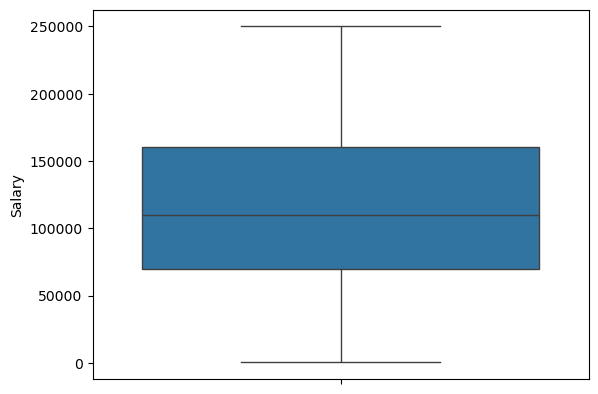

In [25]:
import seaborn as sns
sns.boxplot(data['Salary'])

In [26]:
X = data.drop('Salary', axis=1)
y = data['Salary']

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
X_train_single = X_train[['Years of Experience']]
X_test_single = X_test[['Years of Experience']]

from sklearn.linear_model import LinearRegression

model_single = LinearRegression()
model_single.fit(X_train_single, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
model_multiple = LinearRegression()
model_multiple.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [30]:
y_pred_single = model_single.predict(X_test_single)
y_pred_multiple = model_multiple.predict(X_test)

In [31]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse_single = np.sqrt(mean_squared_error(y_test, y_pred_single))
r2_single = r2_score(y_test, y_pred_single)


rmse_multiple = np.sqrt(mean_squared_error(y_test, y_pred_multiple))
r2_multiple = r2_score(y_test, y_pred_multiple)

print("Single Feature Model:")
print("RMSE:", rmse_single)
print("R2:", r2_single)

print("\nMultiple Feature Model:")
print("RMSE:", rmse_multiple)
print("R2:", r2_multiple)

Single Feature Model:
RMSE: 32081.039800722014
R2: 0.6243738916439696

Multiple Feature Model:
RMSE: 21606.850279968414
R2: 0.8296108941476219


In [32]:
if rmse_multiple < rmse_single:
    best_model = model_multiple
    print("Multiple feature model is better")
else:
    best_model = model_single
    print("Single feature model is better")

Multiple feature model is better


In [33]:
import joblib

joblib.dump(best_model, 'best_salary_model.pkl')

['best_salary_model.pkl']

In [34]:
loaded_model = joblib.load('best_salary_model.pkl')